# Notebook 1B — Scratch CNN Ladder (B0 → B4)

*Restructured for traceability — code, results, and outputs unchanged. Each code cell is preceded by a numbered markdown heading. Cell numbering matches the report's Notebook + Cell references.*

## Cell 1 — Imports


In [ ]:

import os, random, time, math, shutil, zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


## Cell 2 — Configuration + run version


In [ ]:

class CFG:
    # Repro
    seed = 42

    # Data
    img_size = 224
    batch_size = 32

    # Training budget (keep identical in Notebook 2)
    epochs = 50
    patience = 7  # early stopping on val_bacc

    # Optimizer (keep identical in Notebook 2)
    lr = 3e-4
    weight_decay = 1e-4
    clip_grad = 1.0

    # Classes (fixed order; must match across notebooks)
    CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

    # Augment policies (Light vs Strong) — both medical-safe
    AUG_POLICY = "light"  # overridden per ladder step

    # Ladder toggles (overridden per ladder step)
    use_mixup = False
    mixup_alpha = 0.2

    label_smoothing = 0.0  # will be 0.05 at B3/B4

    use_ema = False
    ema_decay = 0.999

    loss_type = "ce"   # ladder uses CE; focal is separate ablation later if needed
    focal_gamma = 1.5

    # Workers/caching
    num_workers_drive = 0
    num_workers_local = 2
    cache_to_local = True
    CACHE_DIR = Path("/content/ham_cache/images")

    # Run versioning (prevents overwriting)
    RUN_VERSION = "CNN_LADDER_B0_B4"

    # Auto-detected paths (filled later)
    DRIVE_ROOT = None
    DATA_ROOT  = None
    CSV_PATH   = None
    IMG_DIR1   = None
    IMG_DIR2   = None
    RUN_DIR    = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Cell 3 — Reproducibility — seed_everything(42)


In [ ]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)


## Cell 4 — Drive mount (Colab-safe)


In [ ]:

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
    print("✅ Drive ready:", os.path.exists("/content/drive/MyDrive"))
else:
    print("ℹ️ Not in Colab (Drive mount skipped)")


Mounted at /content/drive
✅ Drive ready: True


## Cell 5 — Path resolution + versioned RUN_DIR


In [ ]:

def resolve_ham10000_paths():
    search_roots = []
    if IN_COLAB and os.path.exists("/content/drive/MyDrive"):
        search_roots.append(Path("/content/drive/MyDrive"))
    search_roots.append(Path.cwd())

    csv_path = None
    for root in search_roots:
        cands = list(root.rglob("HAM10000_metadata.csv"))
        if len(cands) > 0:
            csv_path = cands[0]
            break
    if csv_path is None:
        raise FileNotFoundError("Could not find HAM10000_metadata.csv. Put HAM10000 folder in Drive or current folder.")

    data_root = csv_path.parent

    img1 = None
    img2 = None
    for root in [data_root] + search_roots:
        c1 = list(root.rglob("HAM10000_images_part_1"))
        c2 = list(root.rglob("HAM10000_images_part_2"))
        if len(c1) > 0 and len(c2) > 0:
            img1, img2 = c1[0], c2[0]
            break
    if img1 is None or img2 is None:
        raise FileNotFoundError("Could not find HAM10000_images_part_1 and HAM10000_images_part_2.")

    drive_root = Path("/content/drive/MyDrive") if (IN_COLAB and os.path.exists("/content/drive/MyDrive")) else Path.cwd()
    return drive_root, data_root, csv_path, img1, img2

CFG.DRIVE_ROOT, CFG.DATA_ROOT, CFG.CSV_PATH, CFG.IMG_DIR1, CFG.IMG_DIR2 = resolve_ham10000_paths()

CFG.RUN_DIR = CFG.DRIVE_ROOT / "ham_runs" / "notebook1_cnn_matched_recipe" / CFG.RUN_VERSION
CFG.RUN_DIR.mkdir(parents=True, exist_ok=True)

print("CSV_PATH:", CFG.CSV_PATH)
print("IMG_DIR1:", CFG.IMG_DIR1)
print("IMG_DIR2:", CFG.IMG_DIR2)
print("RUN_DIR :", CFG.RUN_DIR)


CSV_PATH: /content/drive/MyDrive/HAM10000/HAM10000_metadata.csv
IMG_DIR1: /content/drive/MyDrive/HAM10000/HAM10000_images_part_1
IMG_DIR2: /content/drive/MyDrive/HAM10000/HAM10000_images_part_2
RUN_DIR : /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4


## Cell 6 — Metadata loading + stable label map


In [ ]:

df = pd.read_csv(CFG.CSV_PATH)

label_col = "dx"
imgid_col  = "image_id"
group_col  = "lesion_id"

df = df[df[label_col].isin(CFG.CLASSES)].copy()

class_to_idx = {c: i for i, c in enumerate(CFG.CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["y"] = df[label_col].map(class_to_idx).astype(int)

print("Classes (fixed order):", CFG.CLASSES)
print("Mapping:", class_to_idx)
print("y min/max:", df["y"].min(), df["y"].max())
print("Counts:\n", df[label_col].value_counts())
df[[imgid_col, group_col, label_col, "y"]].head()


Classes (fixed order): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
y min/max: 0 6
Counts:
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,image_id,lesion_id,dx,y
0,ISIC_0027419,HAM_0000118,bkl,2
1,ISIC_0025030,HAM_0000118,bkl,2
2,ISIC_0026769,HAM_0002730,bkl,2
3,ISIC_0025661,HAM_0002730,bkl,2
4,ISIC_0031633,HAM_0001466,bkl,2


## Cell 7 — Image-path index


In [ ]:

def build_img_index(img_dir1: Path, img_dir2: Path):
    idx = {}
    for d in (img_dir1, img_dir2):
        for p in d.glob("*.jpg"):
            idx[p.stem] = p
    return idx

img_index = build_img_index(CFG.IMG_DIR1, CFG.IMG_DIR2)
print("Indexed images:", len(img_index))

paths = []
missing = 0
for img_id in df[imgid_col].values:
    p = img_index.get(img_id, None)
    if p is None:
        paths.append("")
        missing += 1
    else:
        paths.append(str(p))
df["path"] = paths

print("Missing paths:", missing)
df = df[df["path"] != ""].reset_index(drop=True)
print("After drop:", len(df))


Indexed images: 10044
Missing paths: 0
After drop: 10015


## Cell 8 — Lesion-wise group split 



In [ ]:

def group_split(df_in, group_col="lesion_id", test_size=0.15, val_size=0.15, seed=42):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trval_idx, te_idx = next(gss1.split(df_in, groups=df_in[group_col]))
    trval = df_in.iloc[trval_idx].reset_index(drop=True)
    test  = df_in.iloc[te_idx].reset_index(drop=True)

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
    tr_idx, va_idx = next(gss2.split(trval, groups=trval[group_col]))
    train = trval.iloc[tr_idx].reset_index(drop=True)
    val   = trval.iloc[va_idx].reset_index(drop=True)
    return train, val, test

train_df, val_df, test_df = group_split(df, group_col=group_col, test_size=0.15, val_size=0.15, seed=CFG.seed)

print("Sizes:", len(train_df), len(val_df), len(test_df))
print("Train dist:\n", train_df["y"].value_counts().sort_index())
print("Val dist:\n",   val_df["y"].value_counts().sort_index())

assert set(train_df[group_col]).isdisjoint(set(val_df[group_col]))
assert set(train_df[group_col]).isdisjoint(set(test_df[group_col]))
assert set(val_df[group_col]).isdisjoint(set(test_df[group_col]))
print("No lesion_id leakage across splits")


Sizes: 7182 1306 1527
Train dist:
 y
0     226
1     367
2     792
3      92
4     798
5    4809
6      98
Name: count, dtype: int64
Val dist:
 y
0     53
1     81
2    135
3     13
4    129
5    880
6     15
Name: count, dtype: int64
✅ No lesion_id leakage across splits


## Cell 9 — Optional fast cache (ZIP → /content)


In [ ]:

CFG.CACHE_DIR.mkdir(parents=True, exist_ok=True)

def make_drive_zip_if_missing(img_index, zip_path: Path):
    if zip_path.exists():
        print("✅ Zip already exists:", zip_path)
        return
    print("📦 Creating zip in Drive (one-time)...")
    t0 = time.time()
    items = list(img_index.items())
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
        for i, (_, src) in enumerate(items, start=1):
            src = Path(src)
            if src.exists():
                zf.write(src, arcname=src.name)
            if i % 2000 == 0:
                print(f"  ... zipped {i}/{len(items)}")
    print(f"✅ Zip created: {zip_path} | time={(time.time()-t0)/60:.1f} min")

def unzip_to_cache(zip_local: Path, out_dir: Path):
    print("📦 Unzipping to cache...")
    t0 = time.time()
    with zipfile.ZipFile(zip_local, "r") as zf:
        zf.extractall(out_dir)
    print(f"✅ Unzip done | time={(time.time()-t0)/60:.1f} min")

if IN_COLAB and CFG.cache_to_local:
    drive_zip = CFG.DRIVE_ROOT / "HAM10000_cache_images.zip"
    local_zip = Path("/content/HAM10000_cache_images.zip")

    cached_count = len(list(CFG.CACHE_DIR.glob("*.jpg")))
    if cached_count > 9000:
        print(f"✅ Cache already ready: {cached_count} jpg. Skipping caching.")
    else:
        make_drive_zip_if_missing(img_index, drive_zip)
        if not local_zip.exists():
            print("🚀 Copying zip to /content...")
            shutil.copyfile(drive_zip, local_zip)

        for p in CFG.CACHE_DIR.glob("*.jpg"):
            p.unlink()

        unzip_to_cache(local_zip, CFG.CACHE_DIR)

    def to_cache_path(p):
        return str(CFG.CACHE_DIR / Path(p).name)

    for _df in (train_df, val_df, test_df):
        _df["path"] = _df["path"].map(to_cache_path)

    assert Path(train_df["path"].iloc[0]).exists(), "Cache mapping failed."
    print("✅ Using cached paths:", CFG.CACHE_DIR)
else:
    print("ℹ️ Cache disabled — using original paths.")


✅ Zip already exists: /content/drive/MyDrive/HAM10000_cache_images.zip
🚀 Copying zip to /content...
📦 Unzipping to cache...
✅ Unzip done | time=0.4 min
✅ Using cached paths: /content/ham_cache/images


## Cell 10 — Transforms (light vs strong, medical-safe)


In [ ]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tfm_eval = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def get_train_transform(policy: str):
    policy = policy.lower().strip()
    if policy == "strong":
        return T.Compose([
            T.RandomResizedCrop(CFG.img_size, scale=(0.85, 1.0), ratio=(0.90, 1.10)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(20),
            T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.0),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([
        T.RandomResizedCrop(CFG.img_size, scale=(0.90, 1.0), ratio=(0.95, 1.05)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.RandomRotation(15),
        T.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.0),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

print("✅ Transforms helpers ready")


✅ Transforms helpers ready


## Cell 11 — Dataset (robust)


In [ ]:

class HamDataset(Dataset):
    def __init__(self, df, tfm, img_index=None, cache_dir=None):
        self.df = df.reset_index(drop=True)
        self.tfm = tfm
        self.img_index = img_index
        self.cache_dir = Path(cache_dir) if cache_dir else None

    def __len__(self):
        return len(self.df)

    def _repair_if_cached(self, path_str):
        if self.img_index is None or self.cache_dir is None:
            return False
        p = Path(path_str)
        if str(p).startswith(str(self.cache_dir)):
            src = self.img_index.get(p.stem, None)
            if src is None:
                return False
            try:
                p.unlink(missing_ok=True)
                shutil.copyfile(src, p)
                return True
            except Exception:
                return False
        return False

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = row["path"]
        y = int(row["y"])
        try:
            img = Image.open(path); img.load(); img = img.convert("RGB")
        except Exception:
            if self._repair_if_cached(path):
                img = Image.open(path); img.load(); img = img.convert("RGB")
            else:
                j = random.randint(0, len(self.df)-1)
                return self.__getitem__(j)
        return self.tfm(img), torch.tensor(y, dtype=torch.long)

print("✅ Dataset ready")


✅ Dataset ready


## Cell 12 — Loader factory (sampler ON for ladder)


In [ ]:

using_drive = (IN_COLAB and str(train_df["path"].iloc[0]).startswith("/content/drive"))
num_workers = CFG.num_workers_drive if using_drive else CFG.num_workers_local
print("using_drive:", using_drive, "| num_workers:", num_workers)

def make_train_loader(policy: str, use_sampler: bool):
    tfm_train = get_train_transform(policy)
    train_ds = HamDataset(train_df, tfm_train, img_index=img_index, cache_dir=CFG.CACHE_DIR)
    if not use_sampler:
        return DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

    class_counts = train_df["y"].value_counts().sort_index().reindex(range(len(CFG.CLASSES)), fill_value=0).values
    inv_freq = 1.0 / (class_counts + 1e-6)
    sample_weights = train_df["y"].map(lambda y: inv_freq[int(y)]).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler,
                      num_workers=num_workers, pin_memory=True)

val_ds   = HamDataset(val_df,  tfm_eval, img_index=img_index, cache_dir=CFG.CACHE_DIR)
test_ds  = HamDataset(test_df, tfm_eval, img_index=img_index, cache_dir=CFG.CACHE_DIR)
val_loader  = DataLoader(val_ds,  batch_size=CFG.batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print("✅ Loader factories ready")


using_drive: False | num_workers: 2
✅ Loader factories ready


## Cell 13 — StrongCNN architecture (Listing 4.2 source)


In [ ]:

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(p)
        )
    def forward(self, x):
        return self.block(x)

class StrongCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32, p=0.10),
            ConvBlock(32,  64, p=0.15),
            ConvBlock(64, 128, p=0.20),
            ConvBlock(128,256, p=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

print("✅ Model ready")


✅ Model ready


## Cell 14 — Optimiser / scheduler / loss


In [ ]:

from torch.amp import autocast, GradScaler

def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

def make_scaler():
    return GradScaler("cuda") if device.type == "cuda" else GradScaler("cpu")

class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 1.5, weight=None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean": return loss.mean()
        if self.reduction == "sum":  return loss.sum()
        return loss

def make_criterion():
    if CFG.loss_type == "focal":
        return FocalLoss(gamma=CFG.focal_gamma)
    return nn.CrossEntropyLoss(label_smoothing=float(CFG.label_smoothing))

print("Optim/Loss ready")


✅ Optim/Loss ready


## Cell 15 — MixUp + EMA helpers 


In [ ]:

import contextlib

def _rand_beta(alpha: float, device):
    if alpha <= 0:
        return 1.0
    dist = torch.distributions.Beta(alpha, alpha)
    lam = dist.sample().to(device)
    return float(lam)

def mixup_batch(x, y, alpha: float):
    lam = _rand_beta(alpha, x.device)
    if lam < 0.5:
        lam = 1.0 - lam
    idx = torch.randperm(x.size(0), device=x.device)
    x2, y2 = x[idx], y[idx]
    xm = lam * x + (1.0 - lam) * x2
    return xm, y, y2, lam

def mixup_loss(criterion, logits, y1, y2, lam: float):
    return lam * criterion(logits, y1) + (1.0 - lam) * criterion(logits, y2)

class EMA:
    def __init__(self, decay: float = 0.999):
        self.decay = float(decay)
        self.shadow = {}
    @torch.no_grad()
    def init(self, model: nn.Module):
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def update(self, model: nn.Module):
        if not self.shadow:
            self.init(model)
            return
        msd = model.state_dict()
        for k, v in msd.items():
            if k not in self.shadow:
                self.shadow[k] = v.detach().clone()
                continue
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=(1.0 - self.decay))
            else:
                self.shadow[k] = v.detach().clone()

@contextlib.contextmanager
def use_ema_weights(model: nn.Module, ema: EMA):
    if ema is None or not getattr(ema, "shadow", None):
        yield
        return
    backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(ema.shadow, strict=True)
    try:
        yield
    finally:
        model.load_state_dict(backup, strict=True)

print("MixUp + EMA ready")


✅ MixUp + EMA ready


## Cell 16 — Train/eval loops (AMP + grad-clip + MixUp/EMA branches)


In [ ]:

def evaluate(model, loader, criterion, ema=None):
    model.eval()
    ys, ps = [], []
    total_loss = 0.0

    ctx = use_ema_weights(model, ema) if (ema is not None) else contextlib.nullcontext()
    with ctx, torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(1)
            ys.extend(y.detach().cpu().numpy())
            ps.extend(pred.detach().cpu().numpy())

    ys = np.array(ys); ps = np.array(ps)
    acc  = float(accuracy_score(ys, ps))
    bacc = float(balanced_accuracy_score(ys, ps))
    f1  = float(f1_score(ys, ps, average="weighted"))
    cm   = confusion_matrix(ys, ps, labels=list(range(len(CFG.CLASSES))))
    return total_loss/len(loader.dataset), acc, bacc, f1, cm, ys, ps

def train_one_epoch(model, loader, optimizer, scaler, criterion, ema=None, clip_grad=1.0):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if CFG.use_mixup:
            x_in, y1, y2, lam = mixup_batch(x, y, CFG.mixup_alpha)
        else:
            x_in, y1, y2, lam = x, y, y, 1.0

        with autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logits = model(x_in)
            loss = mixup_loss(criterion, logits, y1, y2, lam) if CFG.use_mixup else criterion(logits, y1)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        if clip_grad is not None and clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total_loss += loss.item() * x.size(0)

    return total_loss/len(loader.dataset)

print("✅ Train/Eval loops ready")


✅ Train/Eval loops ready


## Cell 17 — Reporting helpers


In [ ]:

def plot_history(hist_df, title):
    plt.figure(figsize=(10,4))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    plt.title(title + " — Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.plot(hist_df["epoch"], hist_df["val_bacc"], label="val_bacc")
    plt.plot(hist_df["epoch"], hist_df["val_f1"], label="val_f1")
    plt.title(title + " — Metrics")
    plt.xlabel("epoch"); plt.ylabel("metric"); plt.legend()
    plt.show()

def plot_cm(cm, title, labels):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def full_eval_report(model, loader, criterion, ema=None, title=""):
    loss, acc, bacc, f1, cm, y_true, y_pred = evaluate(model, loader, criterion, ema=ema)
    print(f"{title} | loss={loss:.4f} acc={acc:.4f} bacc={bacc:.4f} f1={f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=CFG.CLASSES, digits=4))
    plot_cm(cm, f"{title} — Confusion Matrix", CFG.CLASSES)
    return {"loss":loss, "acc":acc, "bacc":bacc, "f1":f1}


## Cell 18 — Experiment runner (early stop on val_bacc)


In [ ]:

def run_experiment(tag: str, train_loader, val_loader, epochs: int, patience: int):
    seed_everything(CFG.seed)
    model = StrongCNN(len(CFG.CLASSES)).to(device)
    opt = make_optimizer(model)
    scaler = make_scaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = make_criterion()
    ema = EMA(decay=CFG.ema_decay) if CFG.use_ema else None

    best_bacc = -1.0
    bad = 0
    best_path = str(CFG.RUN_DIR / f"best_{tag}.pt")
    hist = []

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, opt, scaler, criterion, ema=ema, clip_grad=CFG.clip_grad)
        va_loss, va_acc, va_bacc, va_f1, _, _, _ = evaluate(model, val_loader, criterion, ema=ema)
        scheduler.step()

        hist.append([ep, tr_loss, va_loss, va_acc, va_bacc, va_f1])

        if va_bacc > best_bacc + 1e-4:
            best_bacc = va_bacc
            if ema is not None and ema.shadow:
                torch.save(ema.shadow, best_path)
            else:
                torch.save(model.state_dict(), best_path)
            bad = 0
        else:
            bad += 1

        print(f"[{tag}] ep {ep:02d} | tr_loss {tr_loss:.4f} | val_loss {va_loss:.4f} | "
              f"val_acc {va_acc:.4f} | val_bacc {va_bacc:.4f} | val_f1 {va_f1:.4f} | bad={bad}")

        if bad >= patience:
            print(f"🛑 Early stopping: no val_bacc improvement for {patience} epochs.")
            break

    hist_df = pd.DataFrame(hist, columns=["epoch","train_loss","val_loss","val_acc","val_bacc","val_f1"])
    hist_csv = CFG.RUN_DIR / f"history_{tag}.csv"
    hist_df.to_csv(hist_csv, index=False)

    summary_path = CFG.RUN_DIR / "results.csv"
    row = {
        "tag": tag,
        "aug_policy": CFG.AUG_POLICY,
        "use_mixup": CFG.use_mixup,
        "mixup_alpha": CFG.mixup_alpha,
        "label_smoothing": CFG.label_smoothing,
        "use_ema": CFG.use_ema,
        "ema_decay": CFG.ema_decay,
        "best_val_bacc": float(best_bacc),
        "best_ckpt": best_path,
        "history_csv": str(hist_csv),
    }
    if summary_path.exists():
        prev = pd.read_csv(summary_path)
        prev = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
        prev.to_csv(summary_path, index=False)
    else:
        pd.DataFrame([row]).to_csv(summary_path, index=False)

    print(f"✅ Saved best ckpt: {best_path}")
    print(f"✅ Saved history  : {hist_csv}")
    return hist_df, best_path


## Cell 19 — Ladder definition B0 → B4


In [ ]:

LADDER = [
    # tag, aug_policy, mixup, label_smoothing, ema
    ("B0_sampler_light",    "light",  False, 0.00, False),
    ("B1_sampler_strong",   "strong", False, 0.00, False),
    ("B2_strong_mixup",     "strong", True,  0.00, False),
    ("B3_mixup_smoothing",  "strong", True,  0.05, False),
    ("B4_mixup_smooth_ema", "strong", True,  0.05, True ),
]
print("✅ Ladder ready:", [x[0] for x in LADDER])


✅ Ladder ready: ['B0_sampler_light', 'B1_sampler_strong', 'B2_strong_mixup', 'B3_mixup_smoothing', 'B4_mixup_smooth_ema']


## Cell 20 — Run the ladder (B0 → B4) — Figure 4.2 source



RUN: B0_sampler_light
[B0_sampler_light] ep 01 | tr_loss 1.5234 | val_loss 1.2343 | val_acc 0.5176 | val_bacc 0.4716 | val_f1 0.5694 | bad=0
[B0_sampler_light] ep 02 | tr_loss 1.3576 | val_loss 1.1631 | val_acc 0.5383 | val_bacc 0.5310 | val_f1 0.5907 | bad=0
[B0_sampler_light] ep 03 | tr_loss 1.2679 | val_loss 1.3988 | val_acc 0.4518 | val_bacc 0.5392 | val_f1 0.5015 | bad=0
[B0_sampler_light] ep 04 | tr_loss 1.1793 | val_loss 1.2571 | val_acc 0.5054 | val_bacc 0.5246 | val_f1 0.5720 | bad=1
[B0_sampler_light] ep 05 | tr_loss 1.1171 | val_loss 1.2286 | val_acc 0.5329 | val_bacc 0.5337 | val_f1 0.5935 | bad=2
[B0_sampler_light] ep 06 | tr_loss 1.0944 | val_loss 1.1778 | val_acc 0.5467 | val_bacc 0.5548 | val_f1 0.6060 | bad=0
[B0_sampler_light] ep 07 | tr_loss 1.0344 | val_loss 0.9645 | val_acc 0.6225 | val_bacc 0.5542 | val_f1 0.6650 | bad=1
[B0_sampler_light] ep 08 | tr_loss 1.0011 | val_loss 0.9605 | val_acc 0.6263 | val_bacc 0.6167 | val_f1 0.6678 | bad=0
[B0_sampler_light] ep 09 

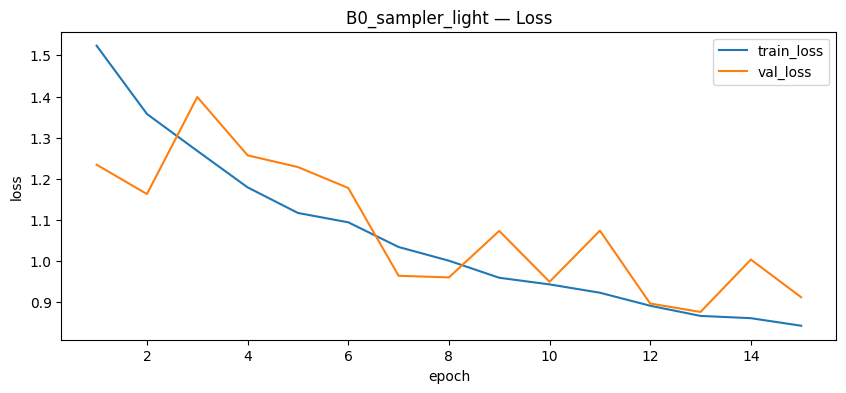

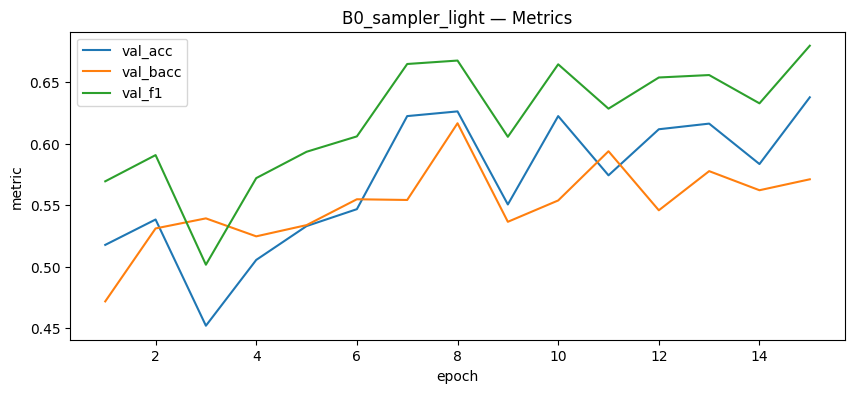


RUN: B1_sampler_strong
[B1_sampler_strong] ep 01 | tr_loss 1.5424 | val_loss 1.3107 | val_acc 0.4893 | val_bacc 0.4567 | val_f1 0.5477 | bad=0
[B1_sampler_strong] ep 02 | tr_loss 1.3821 | val_loss 1.0903 | val_acc 0.5842 | val_bacc 0.5221 | val_f1 0.6204 | bad=0
[B1_sampler_strong] ep 03 | tr_loss 1.3029 | val_loss 1.4077 | val_acc 0.4740 | val_bacc 0.5354 | val_f1 0.5280 | bad=0
[B1_sampler_strong] ep 04 | tr_loss 1.2098 | val_loss 1.3763 | val_acc 0.4564 | val_bacc 0.5055 | val_f1 0.5283 | bad=1
[B1_sampler_strong] ep 05 | tr_loss 1.1350 | val_loss 1.1749 | val_acc 0.5490 | val_bacc 0.5188 | val_f1 0.6081 | bad=2
[B1_sampler_strong] ep 06 | tr_loss 1.1236 | val_loss 1.1761 | val_acc 0.5398 | val_bacc 0.5415 | val_f1 0.5931 | bad=0
[B1_sampler_strong] ep 07 | tr_loss 1.0632 | val_loss 0.9615 | val_acc 0.6057 | val_bacc 0.5339 | val_f1 0.6479 | bad=1
[B1_sampler_strong] ep 08 | tr_loss 1.0309 | val_loss 0.9474 | val_acc 0.6156 | val_bacc 0.5618 | val_f1 0.6591 | bad=0
[B1_sampler_stro

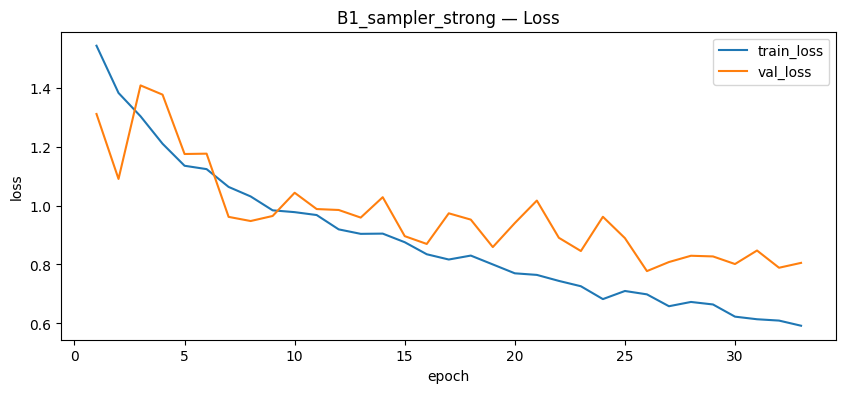

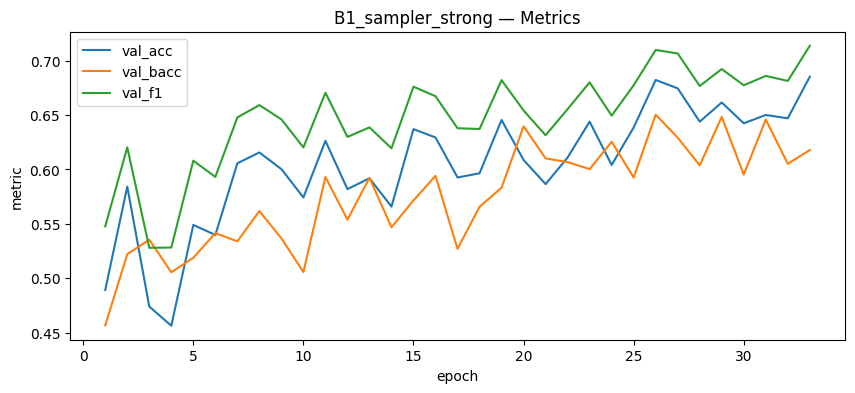


RUN: B2_strong_mixup
[B2_strong_mixup] ep 01 | tr_loss 1.6249 | val_loss 1.3473 | val_acc 0.5023 | val_bacc 0.3991 | val_f1 0.5507 | bad=0
[B2_strong_mixup] ep 02 | tr_loss 1.4904 | val_loss 1.3958 | val_acc 0.4579 | val_bacc 0.4736 | val_f1 0.5133 | bad=0
[B2_strong_mixup] ep 03 | tr_loss 1.4145 | val_loss 1.4059 | val_acc 0.4732 | val_bacc 0.5038 | val_f1 0.5428 | bad=0
[B2_strong_mixup] ep 04 | tr_loss 1.3597 | val_loss 1.2758 | val_acc 0.5084 | val_bacc 0.5013 | val_f1 0.5621 | bad=1
[B2_strong_mixup] ep 05 | tr_loss 1.2915 | val_loss 1.0092 | val_acc 0.5773 | val_bacc 0.5555 | val_f1 0.6227 | bad=0
[B2_strong_mixup] ep 06 | tr_loss 1.2977 | val_loss 1.1225 | val_acc 0.5513 | val_bacc 0.5364 | val_f1 0.6050 | bad=1
[B2_strong_mixup] ep 07 | tr_loss 1.2539 | val_loss 1.0353 | val_acc 0.5590 | val_bacc 0.5874 | val_f1 0.6095 | bad=0
[B2_strong_mixup] ep 08 | tr_loss 1.2193 | val_loss 0.9535 | val_acc 0.6072 | val_bacc 0.5469 | val_f1 0.6484 | bad=1
[B2_strong_mixup] ep 09 | tr_loss 

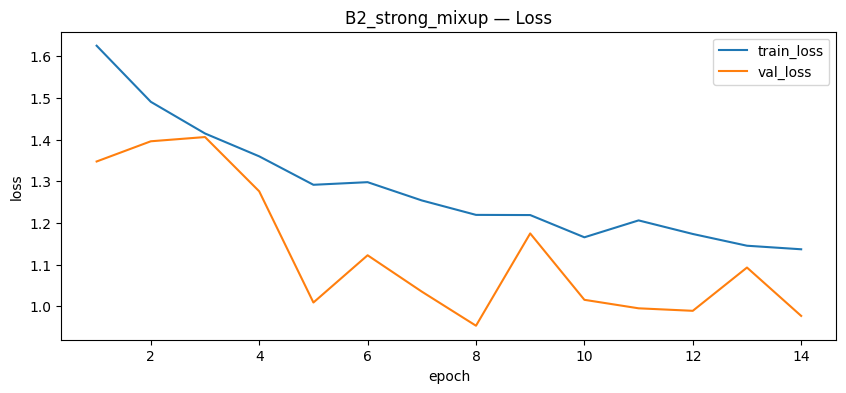

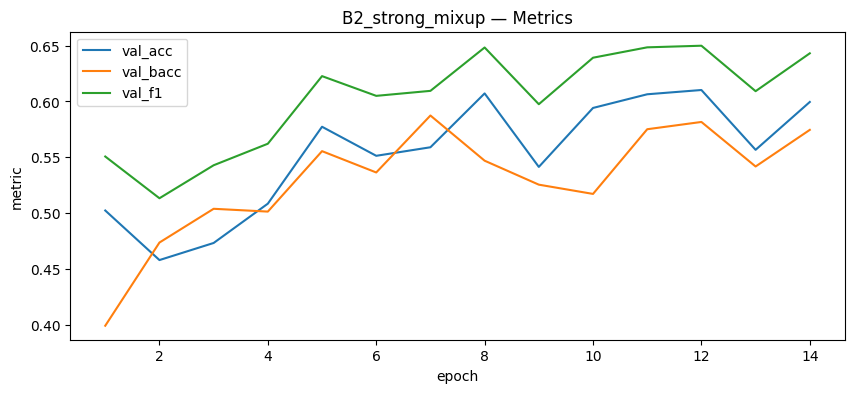


RUN: B3_mixup_smoothing
[B3_mixup_smoothing] ep 01 | tr_loss 1.6543 | val_loss 1.4123 | val_acc 0.5023 | val_bacc 0.4152 | val_f1 0.5526 | bad=0
[B3_mixup_smoothing] ep 02 | tr_loss 1.5425 | val_loss 1.4127 | val_acc 0.4747 | val_bacc 0.4955 | val_f1 0.5277 | bad=0
[B3_mixup_smoothing] ep 03 | tr_loss 1.4711 | val_loss 1.4071 | val_acc 0.5015 | val_bacc 0.5356 | val_f1 0.5633 | bad=0
[B3_mixup_smoothing] ep 04 | tr_loss 1.4138 | val_loss 1.2516 | val_acc 0.5329 | val_bacc 0.5010 | val_f1 0.5884 | bad=1
[B3_mixup_smoothing] ep 05 | tr_loss 1.3559 | val_loss 1.1879 | val_acc 0.5712 | val_bacc 0.5499 | val_f1 0.6181 | bad=0
[B3_mixup_smoothing] ep 06 | tr_loss 1.3617 | val_loss 1.1551 | val_acc 0.5934 | val_bacc 0.5238 | val_f1 0.6361 | bad=1
[B3_mixup_smoothing] ep 07 | tr_loss 1.3245 | val_loss 1.1563 | val_acc 0.5551 | val_bacc 0.5630 | val_f1 0.6072 | bad=0
[B3_mixup_smoothing] ep 08 | tr_loss 1.2934 | val_loss 1.0590 | val_acc 0.6141 | val_bacc 0.5445 | val_f1 0.6511 | bad=1
[B3_mix

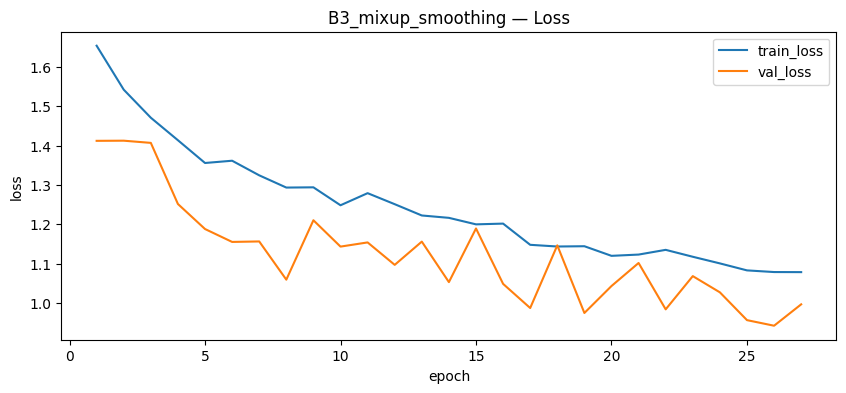

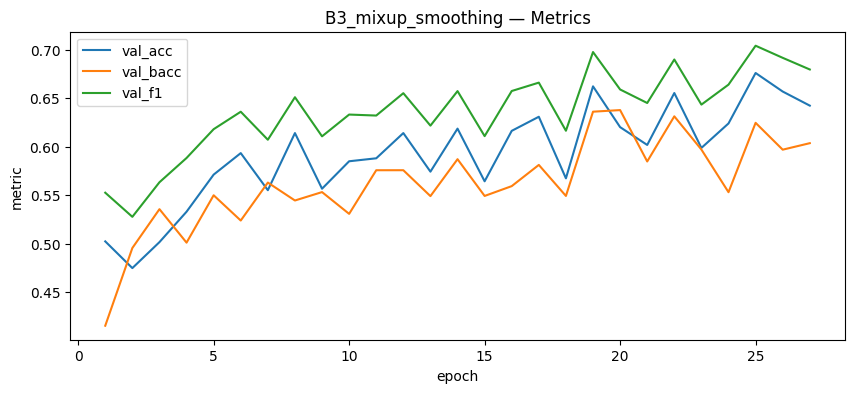


RUN: B4_mixup_smooth_ema
[B4_mixup_smooth_ema] ep 01 | tr_loss 1.6543 | val_loss 1.9443 | val_acc 0.0620 | val_bacc 0.1429 | val_f1 0.0072 | bad=0
[B4_mixup_smooth_ema] ep 02 | tr_loss 1.5425 | val_loss 1.9797 | val_acc 0.0620 | val_bacc 0.1429 | val_f1 0.0072 | bad=1
[B4_mixup_smooth_ema] ep 03 | tr_loss 1.4711 | val_loss 2.0168 | val_acc 0.0620 | val_bacc 0.1429 | val_f1 0.0072 | bad=2
[B4_mixup_smooth_ema] ep 04 | tr_loss 1.4138 | val_loss 2.0285 | val_acc 0.0620 | val_bacc 0.1429 | val_f1 0.0091 | bad=3
[B4_mixup_smooth_ema] ep 05 | tr_loss 1.3559 | val_loss 1.9990 | val_acc 0.0100 | val_bacc 0.1429 | val_f1 0.0002 | bad=4
[B4_mixup_smooth_ema] ep 06 | tr_loss 1.3617 | val_loss 1.9121 | val_acc 0.0115 | val_bacc 0.1432 | val_f1 0.0033 | bad=0
[B4_mixup_smooth_ema] ep 07 | tr_loss 1.3245 | val_loss 1.8292 | val_acc 0.3055 | val_bacc 0.1839 | val_f1 0.4037 | bad=0
[B4_mixup_smooth_ema] ep 08 | tr_loss 1.2934 | val_loss 1.6892 | val_acc 0.4074 | val_bacc 0.1405 | val_f1 0.4643 | bad=

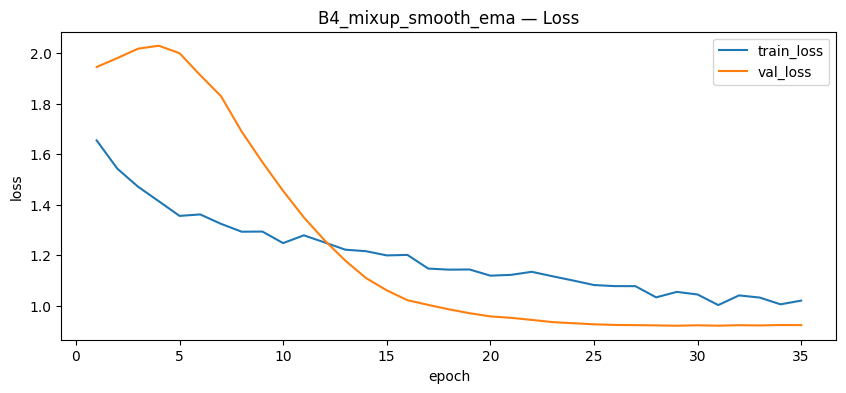

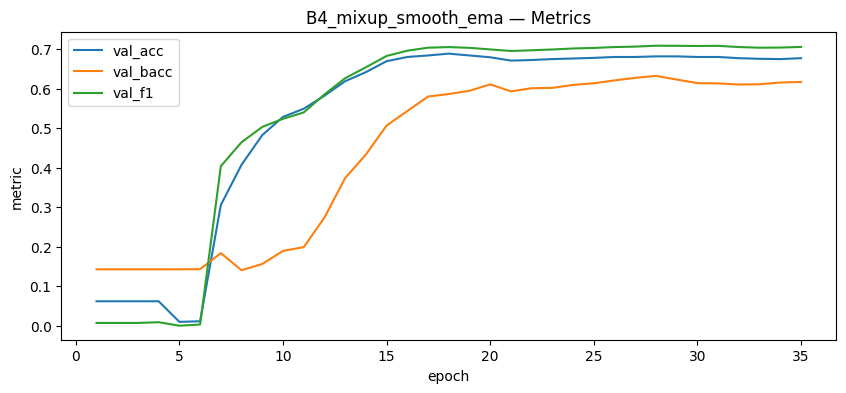


✅ Ladder complete.
B0_sampler_light -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B0_sampler_light.pt
B1_sampler_strong -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B1_sampler_strong.pt
B2_strong_mixup -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B2_strong_mixup.pt
B3_mixup_smoothing -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B3_mixup_smoothing.pt
B4_mixup_smooth_ema -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B4_mixup_smooth_ema.pt


In [ ]:

all_hist = {}
all_best = {}

for tag, aug_policy, use_mixup, ls, use_ema in LADDER:
    print("\n" + "="*100)
    print("RUN:", tag)
    print("="*100)

    CFG.AUG_POLICY = aug_policy
    CFG.use_mixup = use_mixup
    CFG.label_smoothing = float(ls)
    CFG.use_ema = use_ema

    train_loader = make_train_loader(policy=aug_policy, use_sampler=True)

    hist_df, best_path = run_experiment(tag, train_loader, val_loader, CFG.epochs, CFG.patience)
    all_hist[tag] = hist_df
    all_best[tag] = best_path

    plot_history(hist_df, title=tag)

print("\n✅ Ladder complete.")
for k,v in all_best.items():
    print(k, "->", v)


## Cell 21 — Per-rung best collation


In [ ]:
all_best = {
    "B0_sampler_light": "/content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B0_sampler_light.pt",
    "B1_sampler_strong": "/content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B1_sampler_strong.pt",
    "B2_strong_mixup": "/content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B2_strong_mixup.pt",
    "B3_mixup_smoothing": "/content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B3_mixup_smoothing.pt",
    "B4_mixup_smooth_ema": "/content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B4_mixup_smooth_ema.pt",
}

print("✅ Restored checkpoint dictionary:")
for k, v in all_best.items():
    print(k, "->", v)

✅ Restored checkpoint dictionary:
B0_sampler_light -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B0_sampler_light.pt
B1_sampler_strong -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B1_sampler_strong.pt
B2_strong_mixup -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B2_strong_mixup.pt
B3_mixup_smoothing -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B3_mixup_smoothing.pt
B4_mixup_smooth_ema -> /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B4_mixup_smooth_ema.pt


## Cell 22 — TEST eval + per-rung confusion matrices (Tables 4.2, 4.3, Figure 4.3 source)


TEST — B0_sampler_light | loss=1.0078 acc=0.6058 bacc=0.5907 f1=0.6509

Classification report:
              precision    recall  f1-score   support

       akiec     0.2920    0.6875    0.4099        48
         bcc     0.2750    0.3333    0.3014        66
         bkl     0.3644    0.4767    0.4131       172
          df     0.0661    0.8000    0.1221        10
         mel     0.4009    0.4892    0.4407       186
          nv     0.9318    0.6585    0.7716      1016
        vasc     0.4651    0.6897    0.5556        29

    accuracy                         0.6058      1527
   macro avg     0.3993    0.5907    0.4306      1527
weighted avg     0.7402    0.6058    0.6509      1527



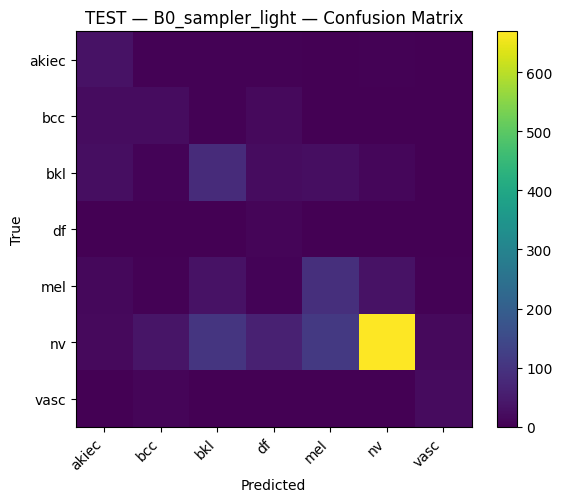

TEST — B1_sampler_strong | loss=0.8312 acc=0.6811 bacc=0.6122 f1=0.7103

Classification report:
              precision    recall  f1-score   support

       akiec     0.3043    0.7292    0.4294        48
         bcc     0.4815    0.5909    0.5306        66
         bkl     0.4947    0.5407    0.5167       172
          df     0.0952    0.4000    0.1538        10
         mel     0.3911    0.5699    0.4639       186
          nv     0.9381    0.7303    0.8213      1016
        vasc     0.5385    0.7241    0.6176        29

    accuracy                         0.6811      1527
   macro avg     0.4633    0.6122    0.5048      1527
weighted avg     0.7687    0.6811    0.7103      1527



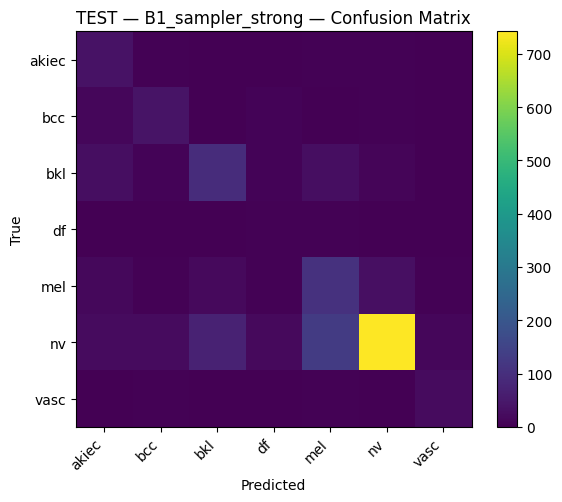

TEST — B2_strong_mixup | loss=1.0527 acc=0.5822 bacc=0.4990 f1=0.6311

Classification report:
              precision    recall  f1-score   support

       akiec     0.2804    0.6250    0.3871        48
         bcc     0.3733    0.4242    0.3972        66
         bkl     0.4741    0.3721    0.4169       172
          df     0.0104    0.1000    0.0189        10
         mel     0.3279    0.7527    0.4568       186
          nv     0.9620    0.5984    0.7379      1016
        vasc     0.3273    0.6207    0.4286        29

    accuracy                         0.5822      1527
   macro avg     0.3936    0.4990    0.4062      1527
weighted avg     0.7647    0.5822    0.6311      1527



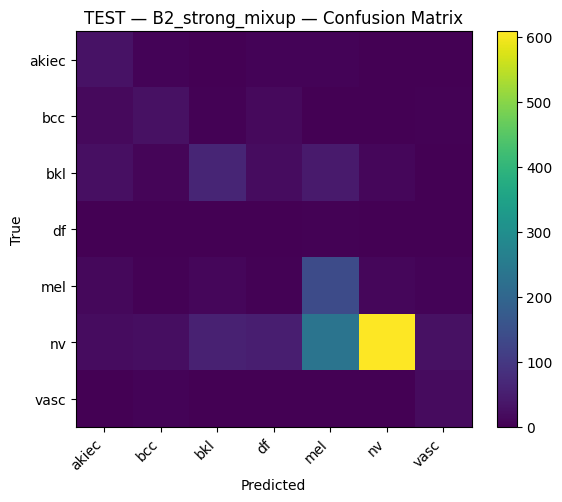

TEST — B3_mixup_smoothing | loss=0.9461 acc=0.6280 bacc=0.6048 f1=0.6646

Classification report:
              precision    recall  f1-score   support

       akiec     0.3043    0.5833    0.4000        48
         bcc     0.4021    0.5909    0.4785        66
         bkl     0.4689    0.5698    0.5144       172
          df     0.1515    0.5000    0.2326        10
         mel     0.3204    0.6237    0.4234       186
          nv     0.9518    0.6417    0.7666      1016
        vasc     0.4286    0.7241    0.5385        29

    accuracy                         0.6280      1527
   macro avg     0.4325    0.6048    0.4791      1527
weighted avg     0.7612    0.6280    0.6646      1527



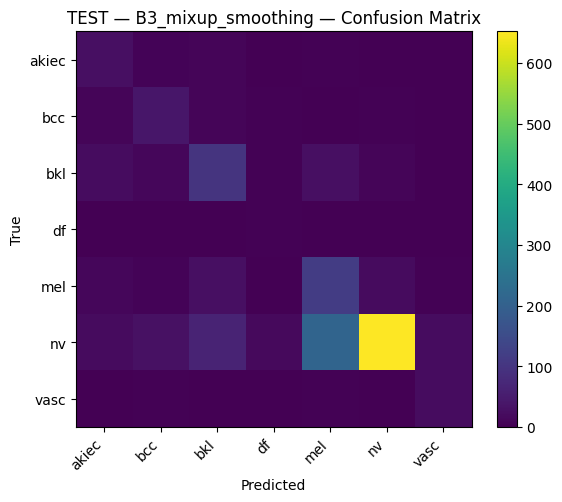

TEST — B4_mixup_smooth_ema | loss=0.8152 acc=0.6876 bacc=0.6163 f1=0.7148

Classification report:
              precision    recall  f1-score   support

       akiec     0.2756    0.7292    0.4000        48
         bcc     0.4706    0.6061    0.5298        66
         bkl     0.5600    0.4884    0.5217       172
          df     0.2105    0.4000    0.2759        10
         mel     0.3824    0.6290    0.4756       186
          nv     0.9398    0.7372    0.8263      1016
        vasc     0.4884    0.7241    0.5833        29

    accuracy                         0.6876      1527
   macro avg     0.4753    0.6163    0.5161      1527
weighted avg     0.7746    0.6876    0.7148      1527



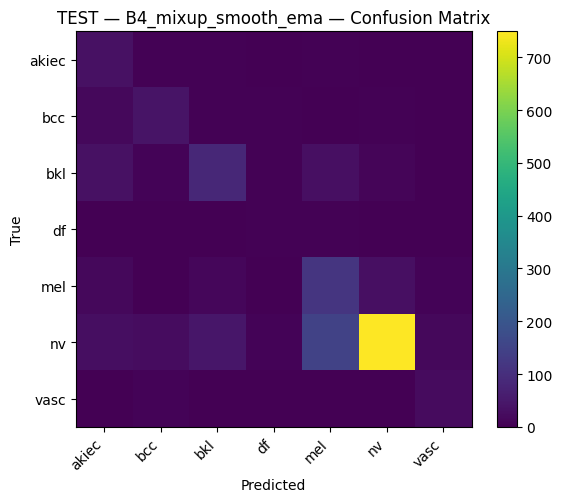


=== TEST Summary (sorted by f1) ===


,tag,acc,bacc,f1,loss
4,B4_mixup_smooth_ema,0.687623,0.616282,0.714813,0.815193
1,B1_sampler_strong,0.681074,0.612160,0.710299,0.831218
3,B3_mixup_smoothing,0.628029,0.604791,0.664587,0.946070
0,B0_sampler_light,0.605763,0.590706,0.650878,1.007800
2,B2_strong_mixup,0.582187,0.499020,0.631142,1.052703


✅ Saved: /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/test_summary.csv


In [ ]:

def load_ckpt(model, ckpt_path: str):
    sd = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(sd, strict=True)
    return model

results = []
for tag, ckpt in all_best.items():
    model = StrongCNN(len(CFG.CLASSES)).to(device)
    model = load_ckpt(model, ckpt)
    crit = make_criterion()
    out = full_eval_report(model, test_loader, crit, ema=None, title=f"TEST — {tag}")
    out["tag"] = tag
    results.append(out)

res_df = pd.DataFrame(results)[["tag","acc","bacc","f1","loss"]].sort_values("f1", ascending=False)
print("\n=== TEST Summary (sorted by f1) ===")
try:
    display(res_df)
except Exception:
    print(res_df)

res_df.to_csv(CFG.RUN_DIR / "test_summary.csv", index=False)
print("✅ Saved:", CFG.RUN_DIR / "test_summary.csv")
